In [64]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, recall_score, precision_score, mean_squared_error, roc_auc_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_wine, load_digits, load_breast_cancer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_selection import RFE
import seaborn as sns
from sklearn.impute import SimpleImputer

In [4]:
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = SVC(kernel='rbf', class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))

0.3333333333333333
0.6190476190476191


In [8]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [13]:
y_pred = model.predict(X_test)

In [14]:
print(mean_squared_error(y_test, y_pred))

1.3320115421348744


In [16]:
documents = ["This is a great movie", "I love this film",
              "Horrible movie, very bad", "Worst film ever"]
labels = [1, 1, 0, 0]

In [17]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(documents)
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, 
                                        random_state=42)

In [18]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
model.predict(X_test)

array([0])

In [21]:
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

In [22]:
model = SVC(kernel='rbf')
model.fit(X, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
xx, yy = np.meshgrid(np.linspace(-2,3,100), np.linspace(-2, 3, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

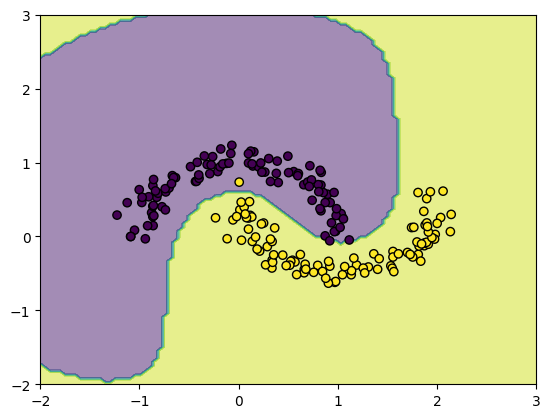

In [24]:
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c = y, edgecolors="k")
plt.show()

In [26]:
messages = ["Win a free IPhone now", 
            "Urgent! Your account is at rist", 
            "Hello, how are you?",
            "Meeting at 3 PM"]
labels = [1, 1, 0, 0]

In [27]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(messages)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, 
                                        random_state=42)

In [29]:
model = MultinomialNB()
model.fit(X_train, y_train)
print(model.predict(X_test))

[0]


In [31]:
X_test.shape

(1, 16)

In [40]:
wine = load_wine()
X, y  = wine.data, wine.target

In [34]:
model = SVC(kernel='linear')

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv)
print(scores.mean())

0.9720634920634922


In [36]:
scores

array([0.94444444, 1.        , 0.94444444, 0.97142857, 1.        ])

In [42]:
digits = load_digits()
X, y = digits.data, digits.target

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                        random_state=42)

In [46]:
model_default = GaussianNB()
model_default.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [47]:
default_acc = accuracy_score(y_test, model_default.predict(X_test))

In [48]:
model_custom = GaussianNB(priors=[0.1] * 10)
model_custom.fit(X_train, y_train)
custom_acc = accuracy_score(y_test, model_custom.predict(X_test))

In [49]:
default_acc

0.8472222222222222

In [50]:
custom_acc

0.8472222222222222

In [52]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
model = SVC(kernel='linear')
selector = RFE(model, n_features_to_select=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [55]:
model.fit(X_train_selected, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [56]:
y_pred = model.predict(X_test_selected)
print(accuracy_score(y_test, y_pred))

0.9736842105263158


In [58]:

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel="rbf", probability=True)
model.fit(X_train, y_train)

# Predict probabilities and compute ROC-AUC score
y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


ROC-AUC Score: 0.9934490664919751


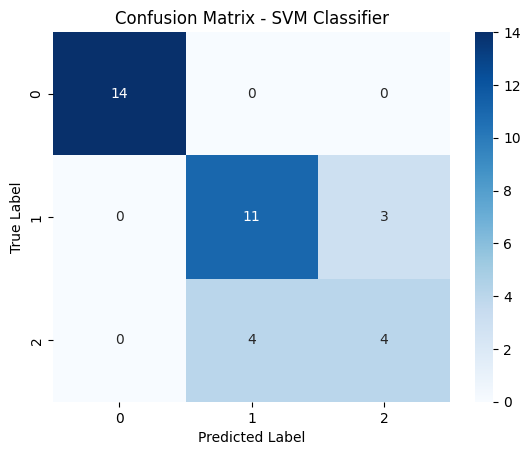

In [60]:

# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel="rbf")
model.fit(X_train, y_train)

# Compute confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM Classifier")
plt.show()


In [62]:
# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall:", recall_score(y_test, y_pred, average='macro'))
print("F1-Score:", f1_score(y_test, y_pred, average='macro'))


Precision: 0.8649844547206135
Recall: 0.8476479221745045
F1-Score: 0.8437352605469787


In [65]:
# Load dataset
wine = load_wine()
X, y = wine.data, wine.target

# Introduce missing values
X[np.random.randint(0, X.shape[0], 10), np.random.randint(0, X.shape[1], 10)] = np.nan

# Handle missing values using SimpleImputer
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Train SVM model
model = SVC(kernel="linear")
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy after handling missing values:", accuracy_score(y_test, y_pred))


Accuracy after handling missing values: 1.0


In [66]:

# Sample dataset
X_train = np.array([[1, 2, 0], [3, 0, 4], [0, 1, 3], [2, 3, 1]])
y_train = np.array([0, 1, 1, 0])

# Train model without smoothing
model_no_smoothing = MultinomialNB(alpha=0)   # No Laplace Smoothing
model_no_smoothing.fit(X_train, y_train)

# Train model with Laplace Smoothing
model_with_smoothing = MultinomialNB(alpha=1)   # With Laplace Smoothing
model_with_smoothing.fit(X_train, y_train)

# Compare predictions
print("Prediction without Smoothing:", model_no_smoothing.predict([[2, 1, 0]]))
print("Prediction with Smoothing:", model_with_smoothing.predict([[2, 1, 0]]))


Prediction without Smoothing: [0]
Prediction with Smoothing: [0]
